# Filter Demonstration: Necessity of Each Filter Stage

This notebook demonstrates the necessity of each filter stage in the LP-based bestline fitting pipeline.

## Filter Configurations

We compare 4 configurations:
1. **Minimal**: Only invalid + baseline filter (Stages 1 & 4)
2. **+ Bin σ**: Add per-bin mean±σ filter (Stages 1, 2, & 4)
3. **+ Global σ**: Add global bin-min filter (Stages 1, 2, 3, & 4)
4. **+ Percentile (Full)**: Add per-bin 5th percentile (all 5 stages)

## Five-Stage Filtering Pipeline

- **Stage 1**: Remove invalid values (zero, negative, inf)
- **Stage 2**: Per-bin mean±1σ filtering (symmetric)
- **Stage 2b**: Per-bin 5th percentile filter
- **Stage 3**: Global bin-min filter (1σ)
- **Stage 4**: Speed-of-light baseline filter

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from rtt_model import (
    RTTDistanceModel, 
    haversine_distance, 
    THEORETICAL_SLOPE,
    fit_bestline_lp,
    filter_rtt_data
)

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['font.size'] = 11

## Load Data

In [6]:
# Load data
data_path = Path('data/vultr_pings_us_only.csv')
df = pd.read_csv(data_path)

# Filter to AS7922 (Comcast)
ASN = 7922
df_asn = df[df['probe_asn'] == float(ASN)].copy()

print(f"Total measurements: {len(df)}")
print(f"AS{ASN} measurements: {len(df_asn)}")
print(f"Unique anchors: {df_asn['dst_ip'].nunique()}")
print(f"Unique probes: {df_asn['src_ip'].nunique()}")

Total measurements: 9866
AS7922 measurements: 1854
Unique anchors: 7
Unique probes: 266


In [7]:
# Calculate distances
df_asn['distance_km'] = df_asn.apply(
    lambda row: haversine_distance(
        row['probe_latitude'], row['probe_longitude'],
        row['anchor_latitude'], row['anchor_longitude']
    ),
    axis=1
)

# Get anchor info
anchors = df_asn[['dst_ip', 'anchor_latitude', 'anchor_longitude', 'anchor_city']].drop_duplicates()
anchors = anchors.rename(columns={
    'dst_ip': 'ip',
    'anchor_latitude': 'lat',
    'anchor_longitude': 'lon',
    'anchor_city': 'city'
})
print(f"\nAnchors:")
for _, a in anchors.iterrows():
    print(f"  {a['ip']}: city - {a['city']}, coord ({a['lat']},{a['lon']})")


Anchors:
  45.77.211.82: city - nan, coord (47.6095,-122.3415)
  66.42.119.57: city - nan, coord (41.9905,-87.9585)
  144.202.18.114: city - nan, coord (33.7795,-84.4205)
  149.28.210.233: city - nan, coord (37.3315,-121.8885)
  149.248.18.65: city - nan, coord (34.0615,-118.2385)
  207.148.2.169: city - nan, coord (32.7905,-96.7915)
  207.246.74.246: city - nan, coord (25.7985,-80.2305)


## Define Filter Configurations

In [8]:
# Filter configurations
FILTER_CONFIGS = {
    '1. Minimal (Invalid + Baseline)': {
        'enable_bin_filter': False,
        'enable_percentile_filter': False,
        'enable_global_filter': False,
        'enable_baseline_filter': True,
        'color': 'red',
        'linestyle': '--'
    },
    '2. + Bin σ Filter': {
        'enable_bin_filter': True,
        'enable_percentile_filter': False,
        'enable_global_filter': False,
        'enable_baseline_filter': True,
        'color': 'orange',
        'linestyle': '-.' 
    },
    '3. + Global σ Filter': {
        'enable_bin_filter': True,
        'enable_percentile_filter': False,
        'enable_global_filter': True,
        'enable_baseline_filter': True,
        'color': 'blue',
        'linestyle': ':'
    },
    '4. Full (+ Percentile)': {
        'enable_bin_filter': True,
        'enable_percentile_filter': True,
        'enable_global_filter': True,
        'enable_baseline_filter': True,
        'color': 'green',
        'linestyle': '-'
    }
}

## Fit Models with Different Filter Configurations

In [9]:
def fit_with_config(distances, rtts, config_name, config):
    """Fit LP bestline with specific filter configuration."""
    result = fit_bestline_lp(
        distances=distances,
        rtts=rtts,
        baseline_slope=THEORETICAL_SLOPE,
        filter_outliers=True,
        bin_size_km=100.0,
        n_std=1.0,
        global_n_std=1.0,
        bin_percentile=0.05,
        enable_bin_filter=config['enable_bin_filter'],
        enable_percentile_filter=config['enable_percentile_filter'],
        enable_global_filter=config['enable_global_filter'],
        enable_baseline_filter=config['enable_baseline_filter']
    )
    return result

In [10]:
# Fit models for each anchor with each configuration
results = {}

for _, anchor in anchors.iterrows():
    anchor_ip = anchor['ip']
    anchor_data = df_asn[df_asn['dst_ip'] == anchor_ip]
    
    distances = anchor_data['distance_km'].values
    rtts = anchor_data['min_rtt'].values
    
    results[anchor_ip] = {
        'city': anchor['city'],
        'distances': distances,
        'rtts': rtts,
        'configs': {}
    }
    
    print(f"\n{anchor['city']} ({anchor_ip}): {len(anchor_data)} measurements")
    
    for config_name, config in FILTER_CONFIGS.items():
        fit_result = fit_with_config(distances, rtts, config_name, config)
        results[anchor_ip]['configs'][config_name] = fit_result
        
        if fit_result['success']:
            print(f"  {config_name}: slope={fit_result['slope']:.5f}, intercept={fit_result['intercept']:.2f}, n={fit_result['n_points']}")
        else:
            print(f"  {config_name}: FAILED - {fit_result['message']}")


nan (45.77.211.82): 264 measurements
  1. Minimal (Invalid + Baseline): slope=0.01106, intercept=0.00, n=261
  2. + Bin σ Filter: slope=0.01776, intercept=4.36, n=191
  3. + Global σ Filter: slope=0.01711, intercept=6.69, n=98
  4. Full (+ Percentile): slope=0.01707, intercept=6.84, n=17

nan (66.42.119.57): 266 measurements
  1. Minimal (Invalid + Baseline): slope=0.01624, intercept=1.34, n=266
  2. + Bin σ Filter: slope=0.01700, intercept=6.33, n=198
  3. + Global σ Filter: slope=0.01325, intercept=12.10, n=112
  4. Full (+ Percentile): slope=0.01310, intercept=12.32, n=17

nan (144.202.18.114): 264 measurements
  1. Minimal (Invalid + Baseline): slope=0.01647, intercept=0.45, n=264
  2. + Bin σ Filter: slope=0.01677, intercept=0.00, n=201
  3. + Global σ Filter: slope=0.01000, intercept=10.16, n=96
  4. Full (+ Percentile): slope=0.01000, intercept=10.16, n=15

nan (149.28.210.233): 266 measurements
  1. Minimal (Invalid + Baseline): slope=0.01355, intercept=0.00, n=265
  2. + Bin 

## Plot: Bestline Comparison for Each Anchor

In [11]:
def plot_filter_comparison(anchor_ip, data, max_rtt_ms=150):
    """Plot RTT-distance scatter with all filter configurations."""
    fig, ax = plt.subplots(figsize=(14, 10))
    
    distances = data['distances']
    rtts = data['rtts']
    city = data['city']
    
    # Filter for plotting
    plot_mask = rtts <= max_rtt_ms
    plot_distances = distances[plot_mask]
    plot_rtts = rtts[plot_mask]
    
    # Plot data points
    ax.scatter(plot_distances, plot_rtts, alpha=0.3, s=20, c='gray', 
               label=f'Measurements (n={len(distances)})', edgecolors='none')
    
    # Distance range for lines
    dist_min, dist_max = distances.min(), distances.max()
    dist_range = np.linspace(dist_min, dist_max, 100)
    
    # Plot theoretical baseline
    theoretical_rtts = THEORETICAL_SLOPE * dist_range
    ax.plot(dist_range, theoretical_rtts, 'k--', linewidth=1.5, alpha=0.5,
            label=f'Theoretical (2/3c): {THEORETICAL_SLOPE:.4f} ms/km')
    
    # Plot bestlines for each configuration
    for config_name, config in FILTER_CONFIGS.items():
        fit_result = data['configs'][config_name]
        if fit_result['success']:
            bestline_rtts = fit_result['slope'] * dist_range + fit_result['intercept']
            label = f"{config_name}: {fit_result['slope']:.4f} ms/km + {fit_result['intercept']:.1f} ms"
            ax.plot(dist_range, bestline_rtts, 
                    color=config['color'], 
                    linestyle=config['linestyle'],
                    linewidth=2.5, label=label)
    
    ax.set_xlabel('Distance (km)', fontsize=12)
    ax.set_ylabel('RTT (ms)', fontsize=12)
    ax.set_title(f'Filter Comparison - {city} ({anchor_ip})\nAS{ASN} Probes', fontsize=14, fontweight='bold')
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, dist_max * 1.05)
    ax.set_ylim(0, max_rtt_ms)
    
    plt.tight_layout()
    return fig

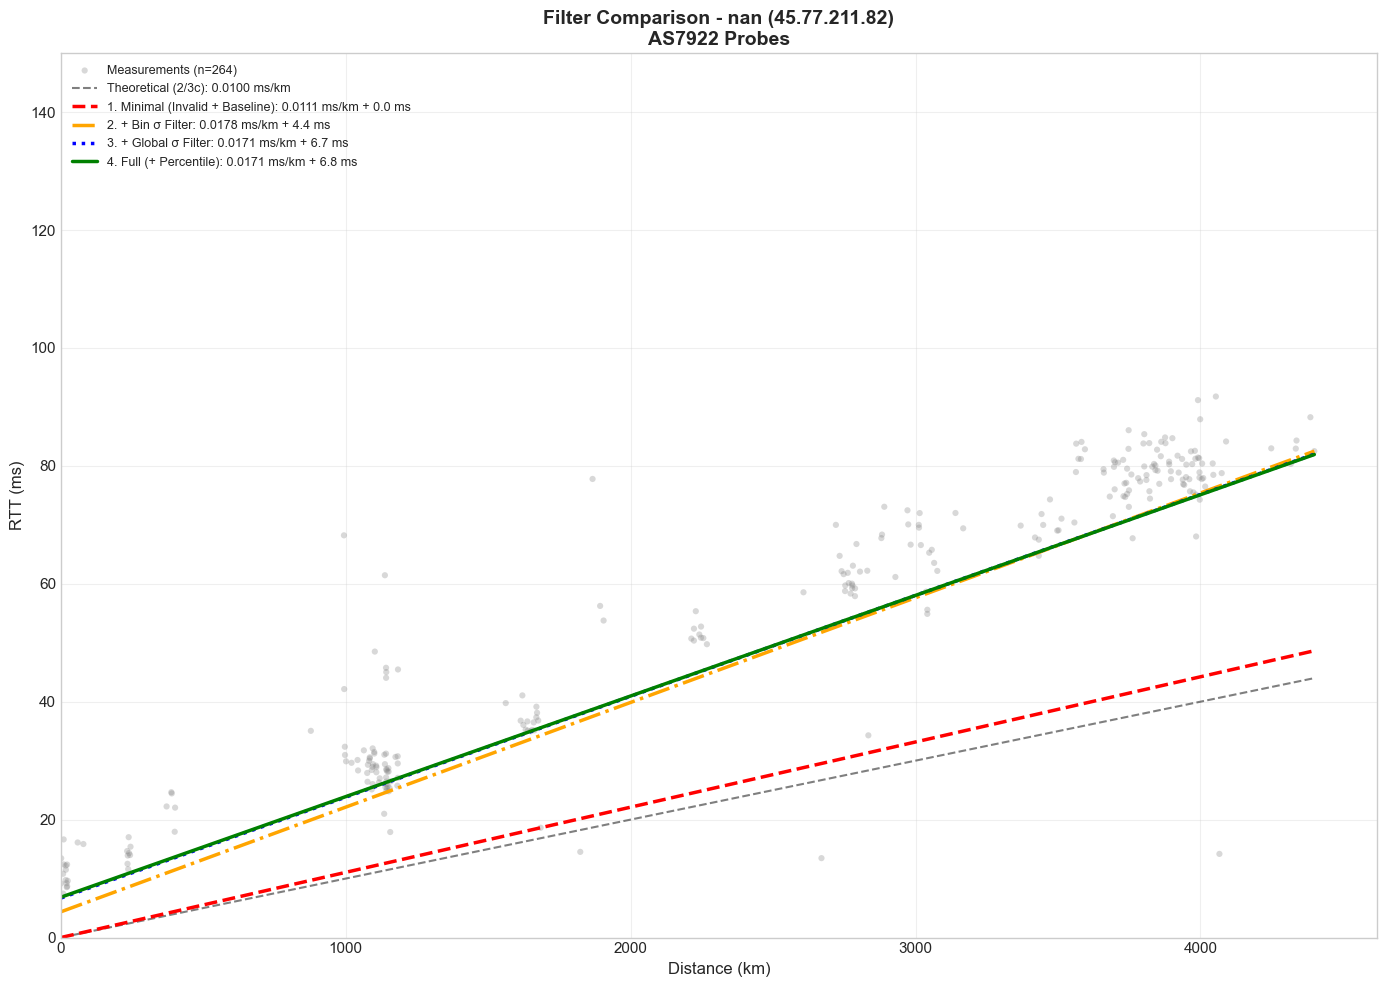

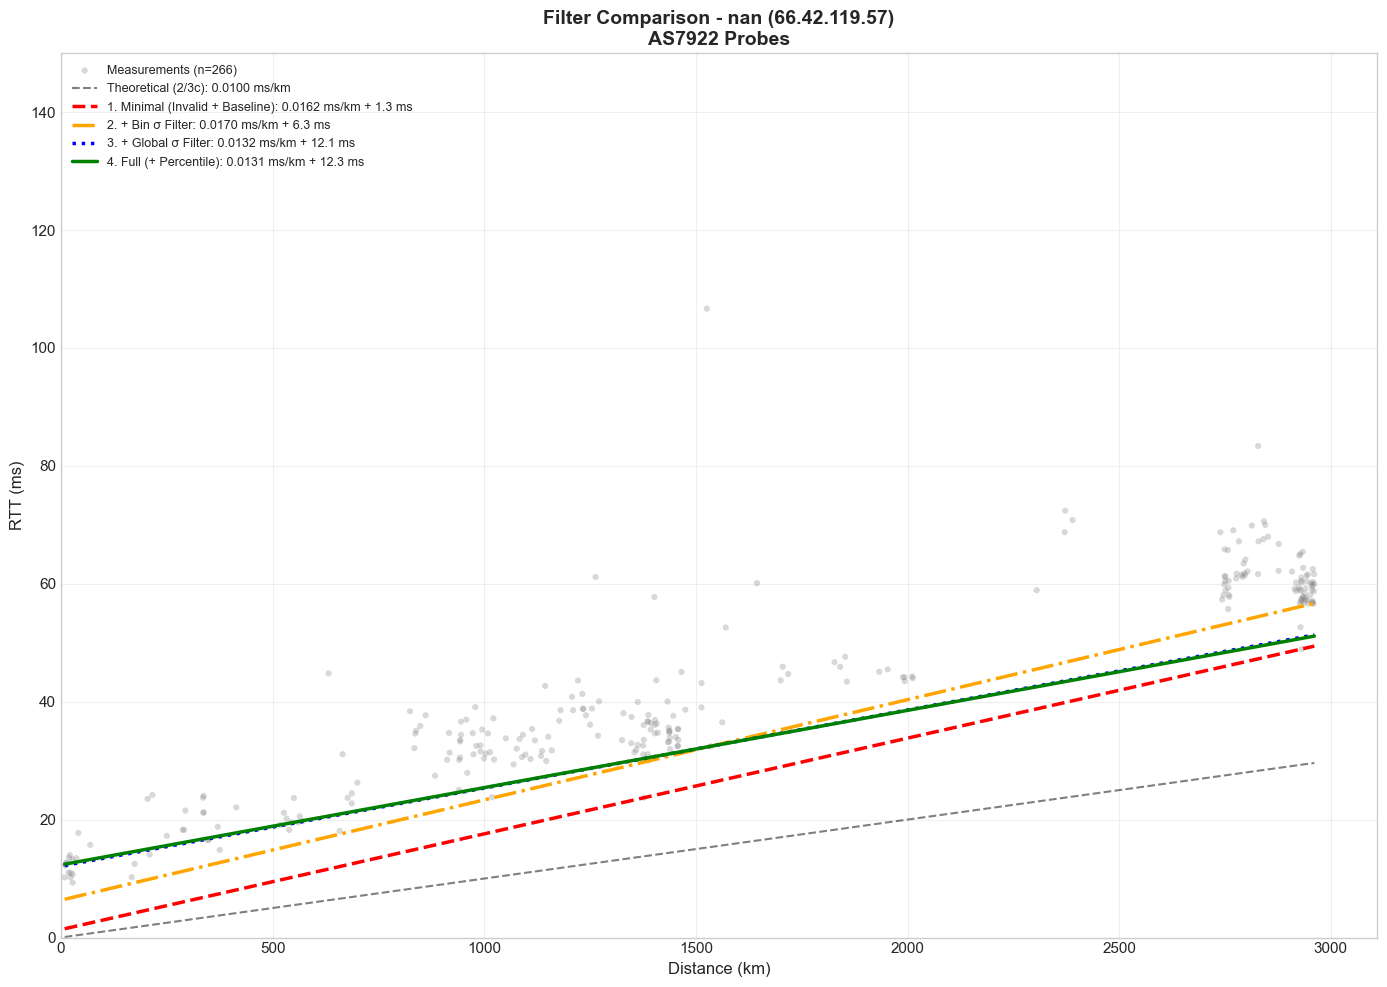

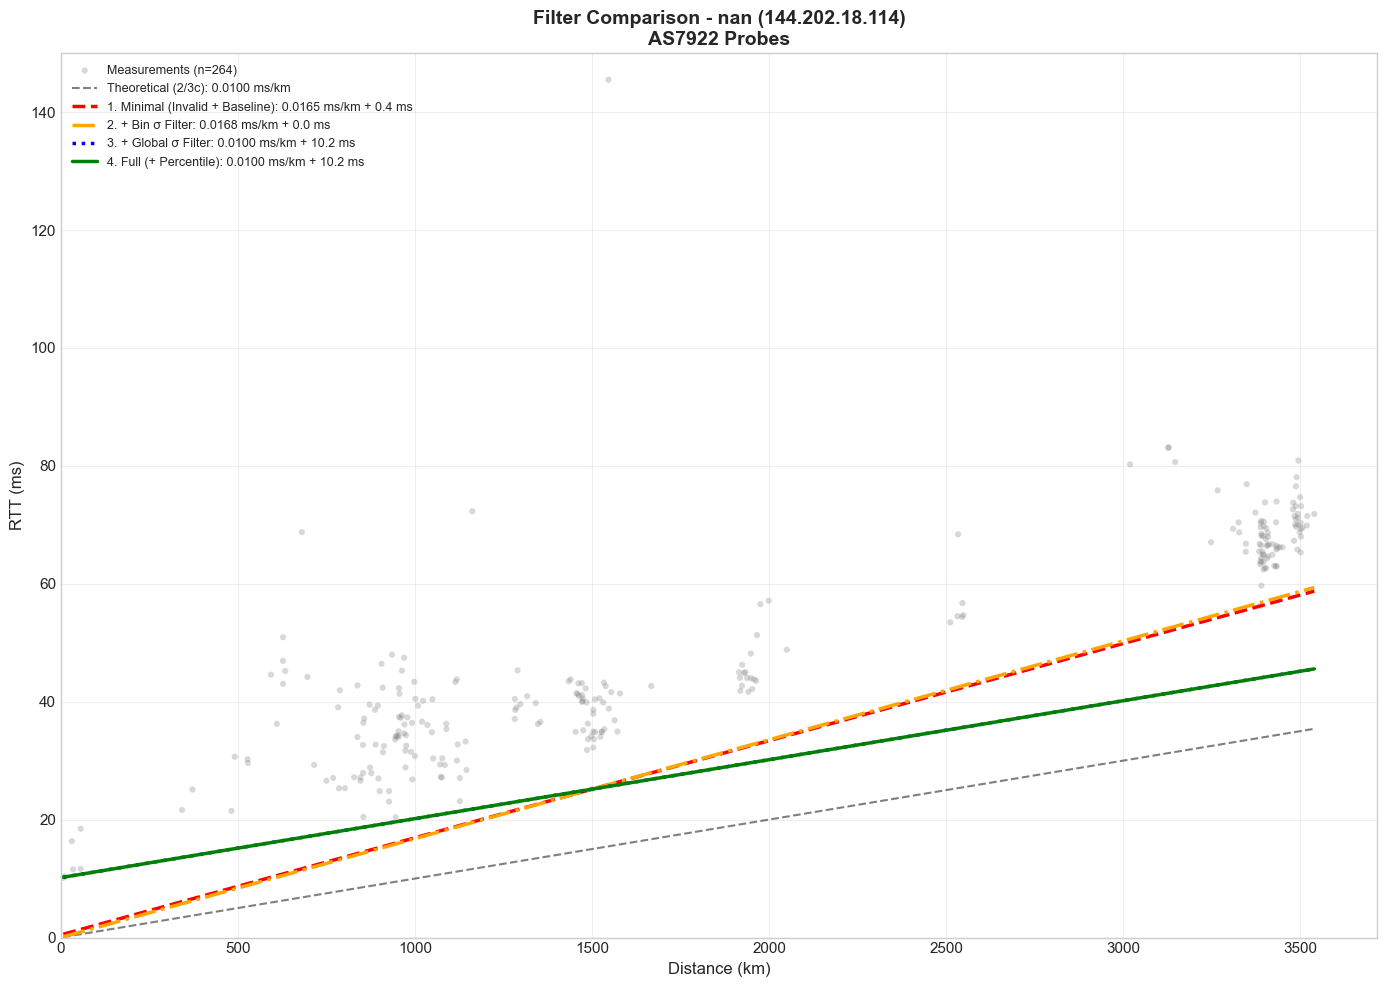

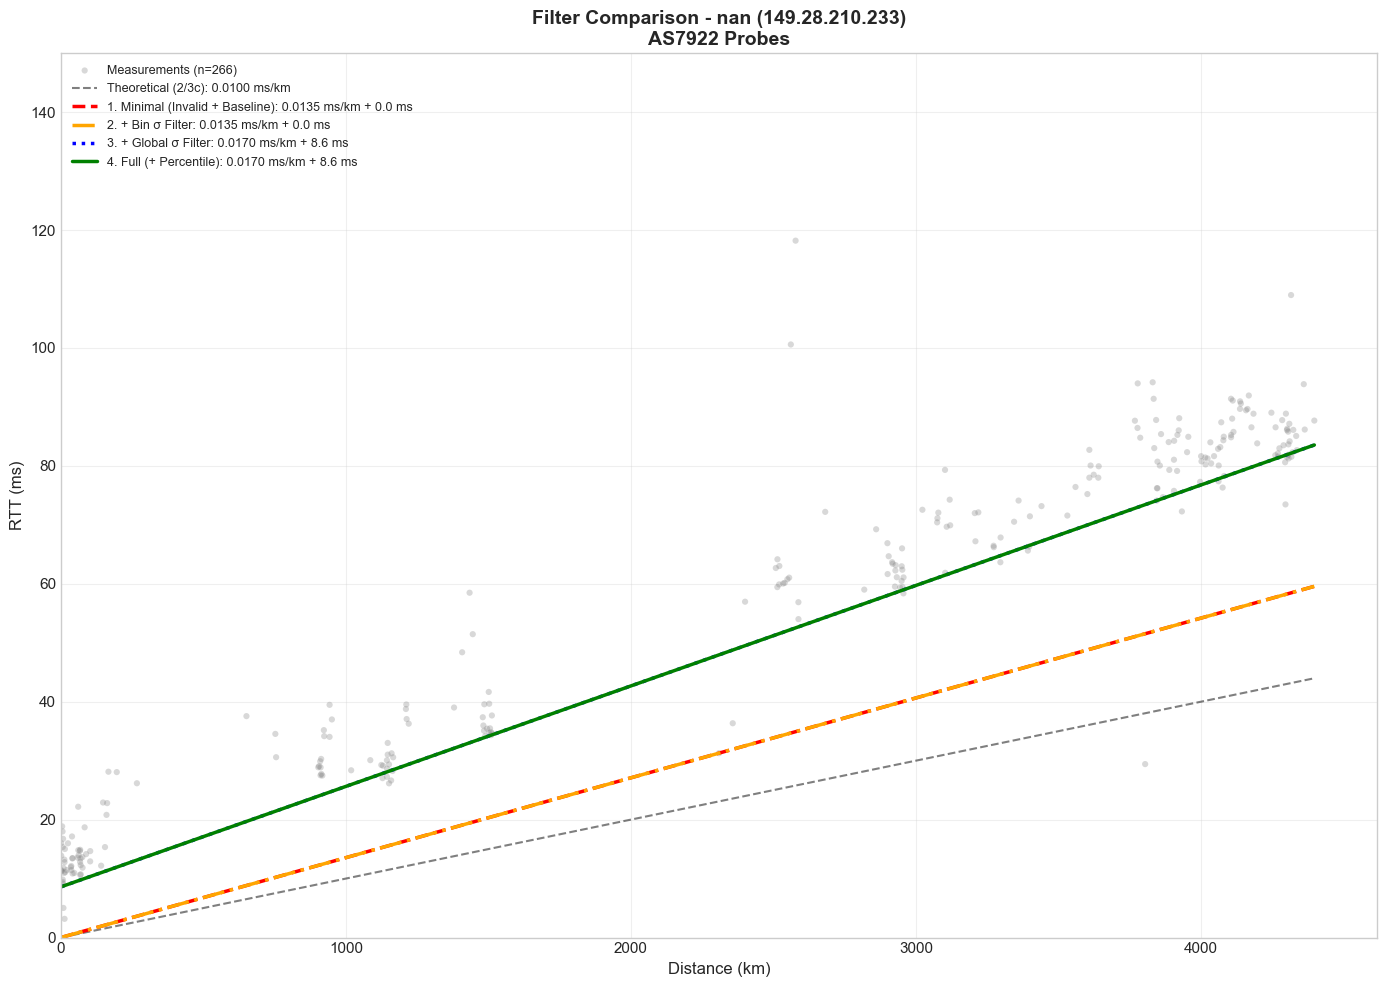

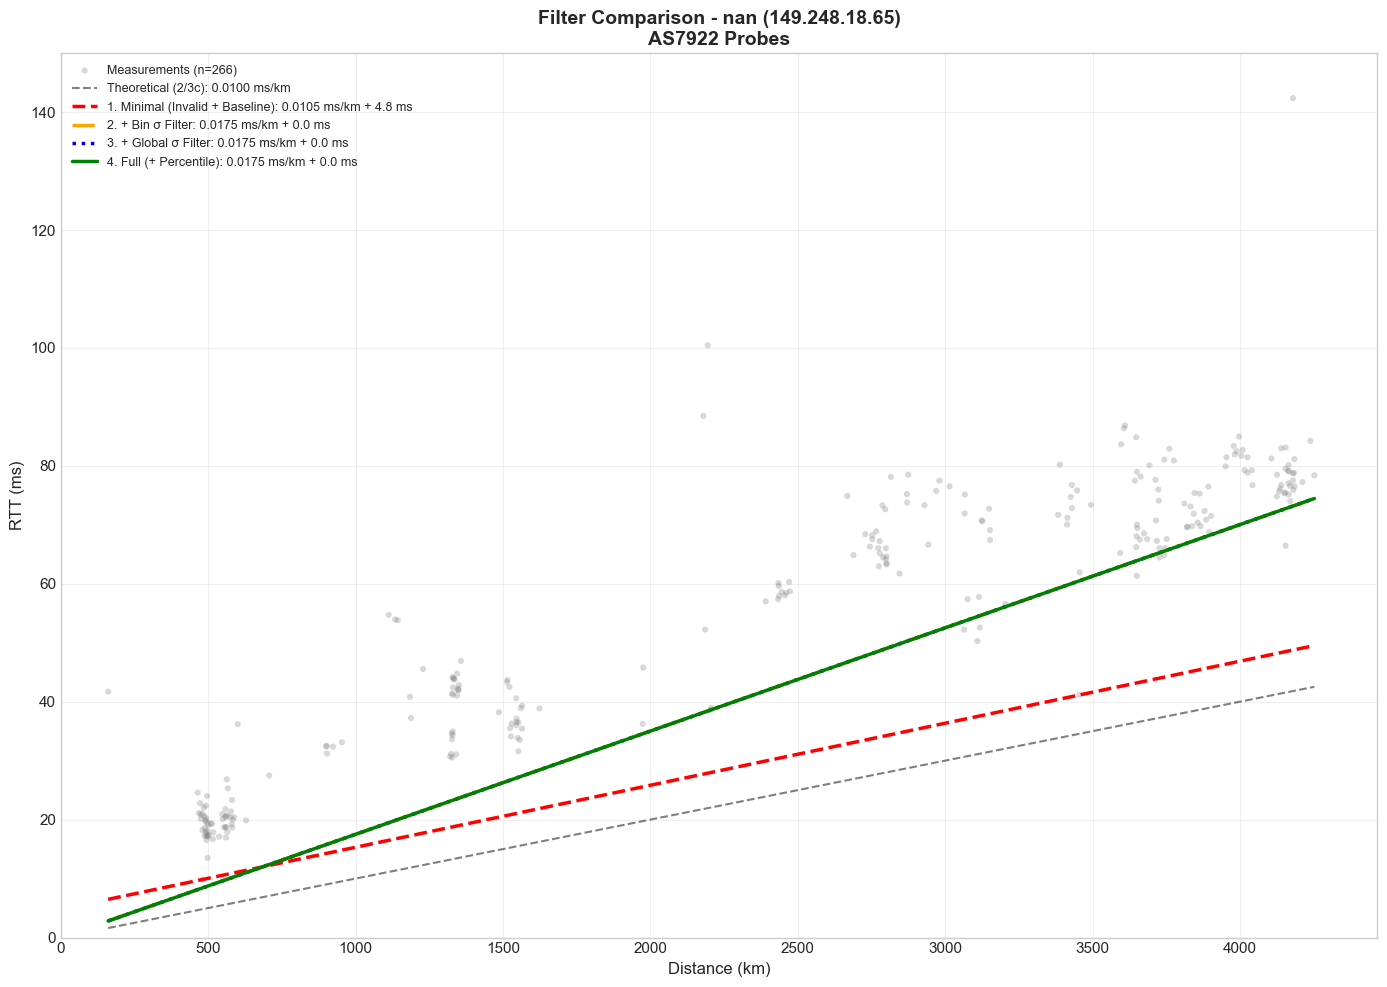

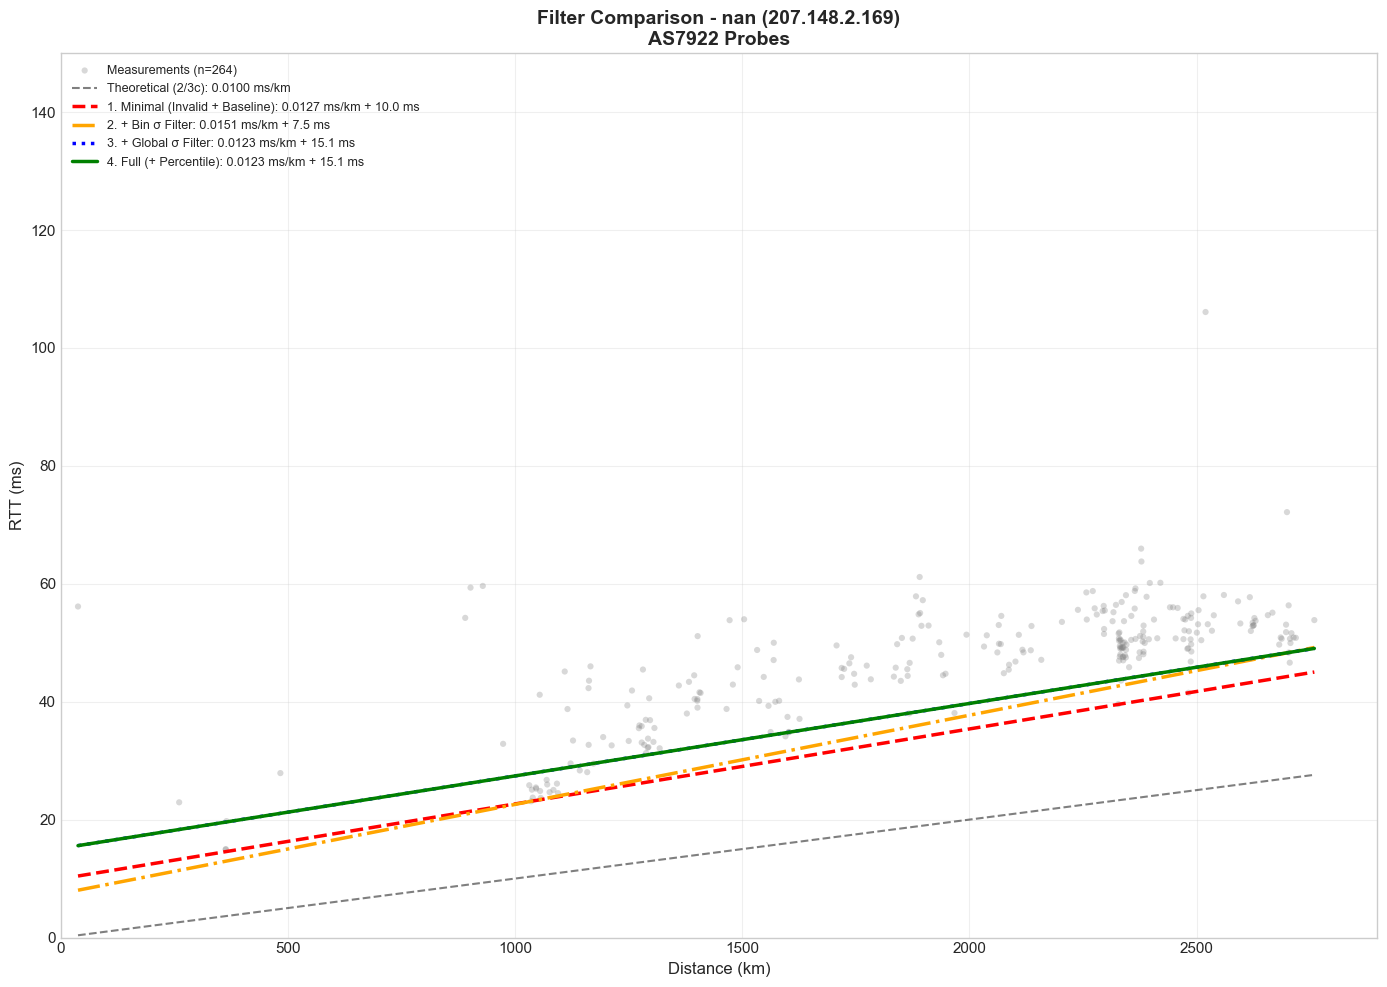

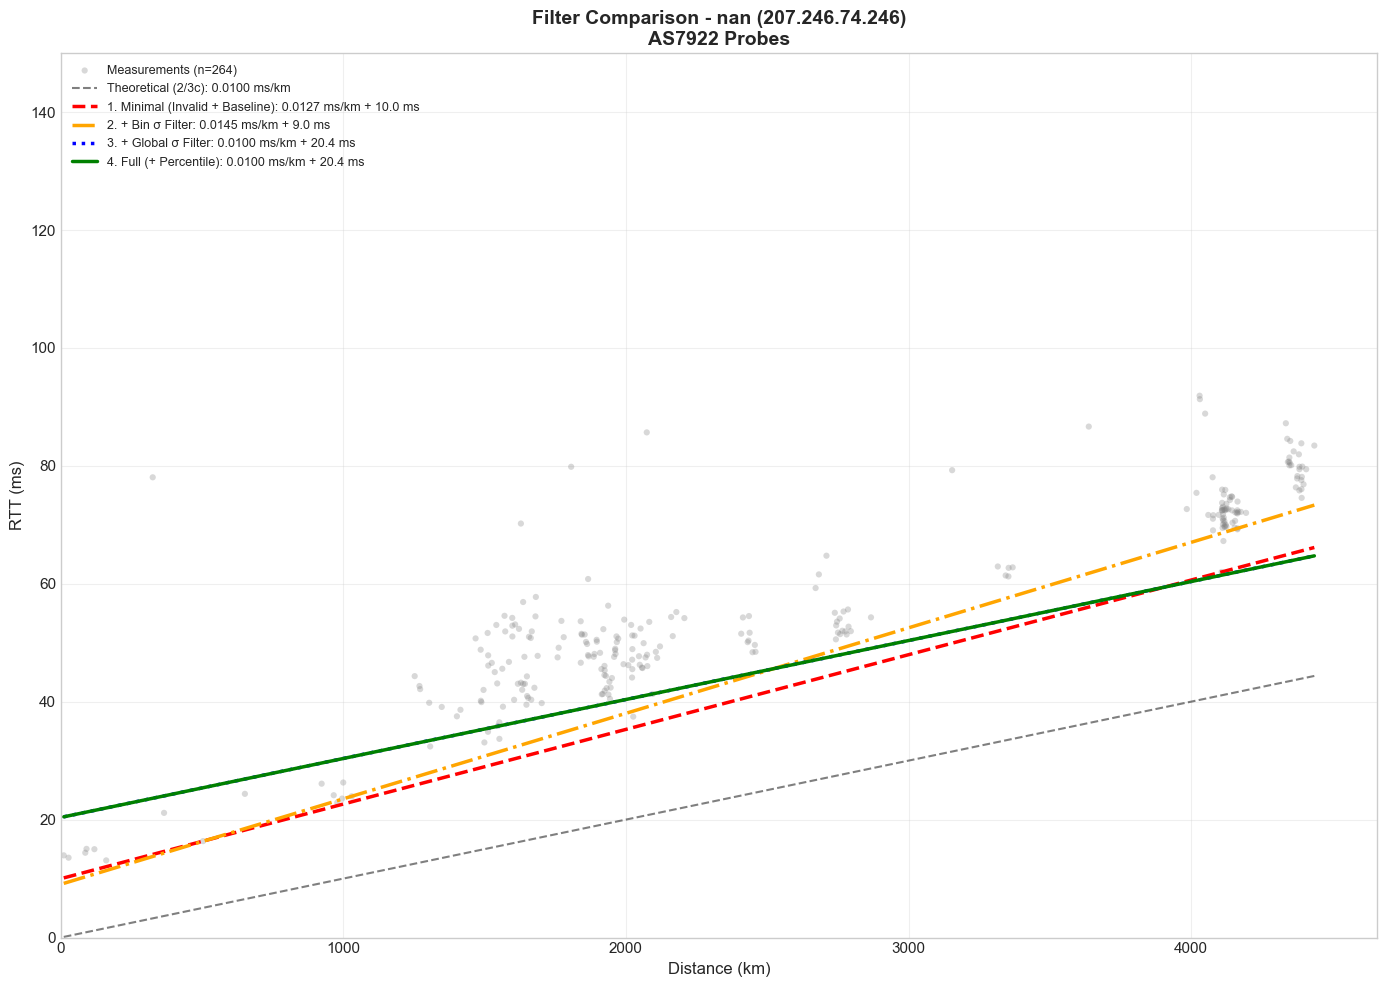

In [12]:
# Generate plots for each anchor
for anchor_ip, data in results.items():
    fig = plot_filter_comparison(anchor_ip, data)
    plt.show()
    plt.close()

## Analysis: Filter Effects

### Observations

1. **Minimal (Invalid + Baseline)**: 
   - Includes all points above speed-of-light
   - High outliers pull the bestline UP
   - Results in inflated slopes

2. **+ Bin σ Filter**:
   - Removes per-bin outliers (both high and low)
   - Provides more stable fits
   - Still may include anomalous bins

3. **+ Global σ Filter**:
   - Removes entire bins with anomalous min RTTs
   - Catches mislabeled coordinates
   - Further stabilizes the fit

4. **Full (+ Percentile)**:
   - Keeps only lowest 5% per bin
   - Creates true lower envelope for LP
   - Most robust against network variability

In [13]:
# Load fitted models from pickle files
from rtt_model import RTTDistanceModel, rtt_to_distance

model_dir = Path('outputs/vultr-7922-rtt-models')
models = {}

for pkl_file in model_dir.glob('*.pkl'):
    model = RTTDistanceModel.load(pkl_file)
    models[model.anchor_ip] = model
    print(f"Loaded model: {model.anchor_ip} (slope={model.slope:.5f}, intercept={model.intercept:.2f})")

print(f"\nTotal models loaded: {len(models)}")

Loaded model: 45.77.211.82 (slope=0.01707, intercept=6.84)
Loaded model: 207.246.74.246 (slope=0.01000, intercept=20.37)
Loaded model: 149.28.210.233 (slope=0.01704, intercept=8.59)
Loaded model: 149.248.18.65 (slope=0.01751, intercept=0.00)
Loaded model: 66.42.119.57 (slope=0.01310, intercept=12.32)
Loaded model: 207.148.2.169 (slope=0.01229, intercept=15.12)
Loaded model: 144.202.18.114 (slope=0.01000, intercept=10.16)

Total models loaded: 7


## Circle Intersection using Shapely

In [14]:
from shapely.geometry import Point, Polygon
from shapely.ops import unary_union

def create_circle_polygon(center_lat, center_lon, radius_km, num_points=64):
    """
    Create a polygon approximation of a circle on Earth's surface.
    
    Args:
        center_lat, center_lon: Circle center (degrees)
        radius_km: Radius in kilometers
        num_points: Number of points for polygon approximation
    
    Returns:
        Shapely Polygon
    """
    # Approximate degrees per km at this latitude
    km_per_deg_lat = 111.0  # roughly constant
    km_per_deg_lon = 111.0 * np.cos(np.radians(center_lat))
    
    # Generate circle points
    angles = np.linspace(0, 2 * np.pi, num_points, endpoint=False)
    
    # Convert radius to degrees
    radius_deg_lat = radius_km / km_per_deg_lat
    radius_deg_lon = radius_km / km_per_deg_lon
    
    # Create circle points
    lons = center_lon + radius_deg_lon * np.cos(angles)
    lats = center_lat + radius_deg_lat * np.sin(angles)
    
    # Create polygon
    coords = list(zip(lons, lats))
    return Polygon(coords)


def find_circles_intersection(circles):
    """
    Find the intersection of multiple circles.
    
    Args:
        circles: List of (center_lat, center_lon, radius_km) tuples
    
    Returns:
        Tuple of (intersection_polygon, centroid_lat, centroid_lon) or (None, None, None)
    """
    if len(circles) == 0:
        return None, None, None
    
    # Create polygon for first circle
    lat, lon, radius = circles[0]
    intersection = create_circle_polygon(lat, lon, radius)
    
    # Intersect with remaining circles
    for lat, lon, radius in circles[1:]:
        circle_poly = create_circle_polygon(lat, lon, radius)
        intersection = intersection.intersection(circle_poly)
        
        if intersection.is_empty:
            return None, None, None
    
    # Get centroid
    centroid = intersection.centroid
    return intersection, centroid.y, centroid.x  # y=lat, x=lon


def estimate_location_fallback(circles):
    """
    Fallback: weighted average of anchor positions (inverse radius weighting).
    Used when circles don't intersect.
    """
    total_weight = 0
    weighted_lat = 0
    weighted_lon = 0
    
    for lat, lon, radius in circles:
        weight = 1.0 / max(radius, 1.0)  # Avoid division by zero
        weighted_lat += lat * weight
        weighted_lon += lon * weight
        total_weight += weight
    
    if total_weight > 0:
        return weighted_lat / total_weight, weighted_lon / total_weight
    return None, None


print("Circle intersection functions defined.")

Circle intersection functions defined.


## CBG Evaluation Function

In [15]:
def evaluate_cbg_probe(probe_ip, probe_data, models):
    """
    Evaluate CBG for a single probe.
    
    Args:
        probe_ip: IP address of the probe
        probe_data: DataFrame with measurements from this probe to all anchors
        models: Dict of anchor_ip -> RTTDistanceModel
    
    Returns:
        Dict with evaluation results
    """
    # Get true probe location (should be same across all rows)
    true_lat = probe_data['probe_latitude'].iloc[0]
    true_lon = probe_data['probe_longitude'].iloc[0]
    
    # Build circles for each anchor
    circles = []
    anchors_used = []
    
    for _, row in probe_data.iterrows():
        anchor_ip = row['dst_ip']
        rtt = row['min_rtt']
        
        if anchor_ip not in models:
            continue
            
        model = models[anchor_ip]
        if not model.fitted:
            continue
        
        # Convert RTT to max distance
        max_distance = model.predict_distance(rtt)
        
        if max_distance is None or max_distance <= 0:
            continue
        
        # Create circle: (anchor_lat, anchor_lon, radius_km)
        circles.append((model.anchor_lat, model.anchor_lon, max_distance))
        anchors_used.append(anchor_ip)
    
    if len(circles) < 2:
        return {
            'probe_ip': probe_ip,
            'true_lat': true_lat,
            'true_lon': true_lon,
            'estimated_lat': None,
            'estimated_lon': None,
            'error_km': None,
            'n_anchors_used': len(circles),
            'method': 'failed'
        }
    
    # Try intersection
    intersection, est_lat, est_lon = find_circles_intersection(circles)
    method = 'intersection'
    
    # If intersection fails, use fallback
    if est_lat is None:
        est_lat, est_lon = estimate_location_fallback(circles)
        method = 'fallback'
    
    if est_lat is None:
        return {
            'probe_ip': probe_ip,
            'true_lat': true_lat,
            'true_lon': true_lon,
            'estimated_lat': None,
            'estimated_lon': None,
            'error_km': None,
            'n_anchors_used': len(circles),
            'method': 'failed'
        }
    
    # Calculate error
    error_km = haversine_distance(true_lat, true_lon, est_lat, est_lon)
    
    return {
        'probe_ip': probe_ip,
        'true_lat': true_lat,
        'true_lon': true_lon,
        'estimated_lat': est_lat,
        'estimated_lon': est_lon,
        'error_km': error_km,
        'n_anchors_used': len(circles),
        'method': method
    }


def evaluate_cbg_all_probes(df, models, asn=7922):
    """
    Evaluate CBG on all probes of target ASN.
    
    Args:
        df: DataFrame with all measurements
        models: Dict of anchor_ip -> RTTDistanceModel
        asn: Target ASN to evaluate
    
    Returns:
        List of evaluation result dicts
    """
    # Filter to target ASN
    df_asn = df[df['probe_asn'] == float(asn)].copy()
    
    # Get unique probes
    probe_ips = df_asn['src_ip'].unique()
    
    results = []
    for probe_ip in probe_ips:
        probe_data = df_asn[df_asn['src_ip'] == probe_ip]
        result = evaluate_cbg_probe(probe_ip, probe_data, models)
        results.append(result)
    
    return results


print("CBG evaluation functions defined.")

CBG evaluation functions defined.


## Run CBG Evaluation

In [16]:
# Run evaluation on all AS7922 probes
evaluation_results = evaluate_cbg_all_probes(df, models, asn=ASN)

# Convert to DataFrame
eval_df = pd.DataFrame(evaluation_results)

# Summary
print(f"Total probes evaluated: {len(eval_df)}")
print(f"Successful (intersection): {len(eval_df[eval_df['method'] == 'intersection'])}")
print(f"Successful (fallback): {len(eval_df[eval_df['method'] == 'fallback'])}")
print(f"Failed: {len(eval_df[eval_df['method'] == 'failed'])}")

# Filter to successful results
eval_success = eval_df[eval_df['error_km'].notna()].copy()
print(f"\nProbes with valid error: {len(eval_success)}")

Total probes evaluated: 266
Successful (intersection): 245
Successful (fallback): 21
Failed: 0

Probes with valid error: 266


## Error Distance CDF

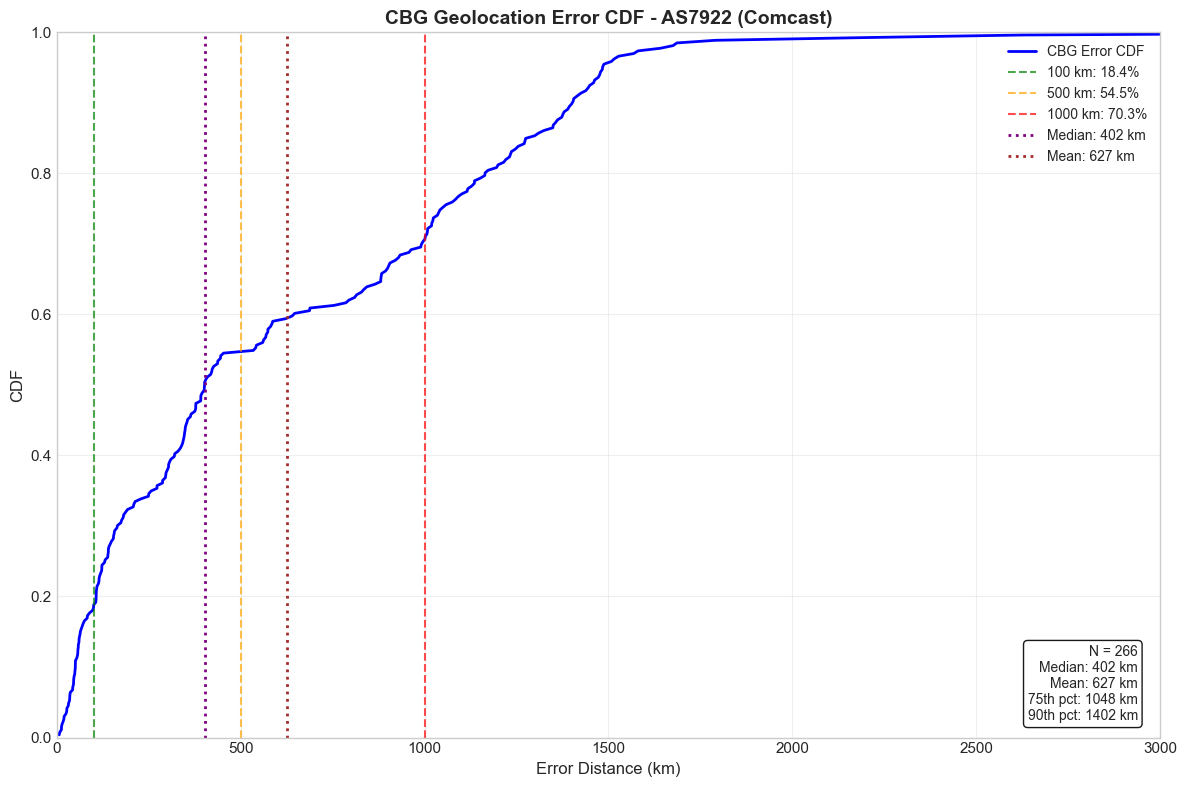

In [17]:
def plot_error_cdf(errors, title="CBG Geolocation Error CDF", output_path=None):
    """
    Plot CDF of geolocation errors.
    
    Args:
        errors: Array of error distances (km)
        title: Plot title
        output_path: Optional path to save figure
    """
    errors = np.array(errors)
    errors_sorted = np.sort(errors)
    cdf = np.arange(1, len(errors_sorted) + 1) / len(errors_sorted)
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Plot CDF
    ax.plot(errors_sorted, cdf, 'b-', linewidth=2, label='CBG Error CDF')
    
    # Add vertical lines for key thresholds
    thresholds = [100, 500, 1000]
    colors = ['green', 'orange', 'red']
    
    for thresh, color in zip(thresholds, colors):
        pct_within = np.mean(errors <= thresh) * 100
        ax.axvline(x=thresh, color=color, linestyle='--', alpha=0.7, 
                   label=f'{thresh} km: {pct_within:.1f}%')
    
    # Add median and mean lines
    median_error = np.median(errors)
    mean_error = np.mean(errors)
    
    ax.axvline(x=median_error, color='purple', linestyle=':', linewidth=2,
               label=f'Median: {median_error:.0f} km')
    ax.axvline(x=mean_error, color='brown', linestyle=':', linewidth=2,
               label=f'Mean: {mean_error:.0f} km')
    
    ax.set_xlabel('Error Distance (km)', fontsize=12)
    ax.set_ylabel('CDF', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, min(errors_sorted.max() * 1.05, 3000))
    ax.set_ylim(0, 1)
    
    # Add statistics text box
    p75 = np.percentile(errors, 75)
    p90 = np.percentile(errors, 90)
    stats_text = (
        f"N = {len(errors)}\n"
        f"Median: {median_error:.0f} km\n"
        f"Mean: {mean_error:.0f} km\n"
        f"75th pct: {p75:.0f} km\n"
        f"90th pct: {p90:.0f} km"
    )
    ax.text(0.98, 0.02, stats_text, transform=ax.transAxes,
            fontsize=10, verticalalignment='bottom', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
    
    plt.tight_layout()
    
    if output_path:
        plt.savefig(output_path, dpi=150, bbox_inches='tight')
        print(f"Saved: {output_path}")
    
    return fig


# Plot CDF
errors = eval_success['error_km'].values
fig = plot_error_cdf(errors, title=f"CBG Geolocation Error CDF - AS{ASN} (Comcast)")
plt.show()

## Detailed Statistics

In [18]:
# Print detailed statistics
errors = eval_success['error_km'].values

print("=" * 60)
print("CBG GEOLOCATION ERROR STATISTICS")
print("=" * 60)
print(f"\nDataset: AS{ASN} (Comcast) probes to 7 Vultr anchors")
print(f"Total probes evaluated: {len(eval_df)}")
print(f"Successful estimations: {len(eval_success)}")
print(f"  - Via intersection: {len(eval_success[eval_success['method'] == 'intersection'])}")
print(f"  - Via fallback: {len(eval_success[eval_success['method'] == 'fallback'])}")

print(f"\nError Statistics:")
print(f"  Median: {np.median(errors):.1f} km")
print(f"  Mean:   {np.mean(errors):.1f} km")
print(f"  Std:    {np.std(errors):.1f} km")
print(f"  Min:    {np.min(errors):.1f} km")
print(f"  Max:    {np.max(errors):.1f} km")

print(f"\nPercentiles:")
for p in [25, 50, 75, 90, 95]:
    print(f"  {p}th: {np.percentile(errors, p):.1f} km")

print(f"\nAccuracy at thresholds:")
for thresh in [50, 100, 250, 500, 1000]:
    pct = np.mean(errors <= thresh) * 100
    print(f"  Within {thresh:4d} km: {pct:5.1f}%")

print("=" * 60)

CBG GEOLOCATION ERROR STATISTICS

Dataset: AS7922 (Comcast) probes to 7 Vultr anchors
Total probes evaluated: 266
Successful estimations: 266
  - Via intersection: 245
  - Via fallback: 21

Error Statistics:
  Median: 402.0 km
  Mean:   626.5 km
  Std:    567.6 km
  Min:    6.6 km
  Max:    3980.6 km

Percentiles:
  25th: 133.2 km
  50th: 402.0 km
  75th: 1048.0 km
  90th: 1402.1 km
  95th: 1484.3 km

Accuracy at thresholds:
  Within   50 km:   9.4%
  Within  100 km:  18.4%
  Within  250 km:  34.2%
  Within  500 km:  54.5%
  Within 1000 km:  70.3%


## Save Results

In [19]:
import json

# Save CDF plot
output_dir = Path('outputs/vultr-7922-rtt-models')
output_dir.mkdir(parents=True, exist_ok=True)

fig = plot_error_cdf(errors, title=f"CBG Geolocation Error CDF - AS{ASN} (Comcast)",
                     output_path=output_dir / 'error_cdf.png')
plt.close()

# Save evaluation results to JSON
eval_json = {
    'asn': ASN,
    'total_probes': len(eval_df),
    'successful_probes': len(eval_success),
    'method_intersection': int(len(eval_success[eval_success['method'] == 'intersection'])),
    'method_fallback': int(len(eval_success[eval_success['method'] == 'fallback'])),
    'statistics': {
        'median_km': float(np.median(errors)),
        'mean_km': float(np.mean(errors)),
        'std_km': float(np.std(errors)),
        'min_km': float(np.min(errors)),
        'max_km': float(np.max(errors)),
        'p25_km': float(np.percentile(errors, 25)),
        'p75_km': float(np.percentile(errors, 75)),
        'p90_km': float(np.percentile(errors, 90)),
        'p95_km': float(np.percentile(errors, 95)),
    },
    'accuracy_thresholds': {
        'within_50km': float(np.mean(errors <= 50) * 100),
        'within_100km': float(np.mean(errors <= 100) * 100),
        'within_250km': float(np.mean(errors <= 250) * 100),
        'within_500km': float(np.mean(errors <= 500) * 100),
        'within_1000km': float(np.mean(errors <= 1000) * 100),
    },
    'probes': eval_df.to_dict(orient='records')
}

with open(output_dir / 'evaluation_results.json', 'w') as f:
    json.dump(eval_json, f, indent=2)

print(f"Saved: {output_dir / 'error_cdf.png'}")
print(f"Saved: {output_dir / 'evaluation_results.json'}")

Saved: outputs/vultr-7922-rtt-models/error_cdf.png
Saved: outputs/vultr-7922-rtt-models/error_cdf.png
Saved: outputs/vultr-7922-rtt-models/evaluation_results.json


## Octant Model Visualization

Compare Octant dual-bound approach with LP bestline:
- **Convex Hull Bounds**: Upper (R_L) and lower (r_L) facets
- **Polynomial Fit**: Quadratic fit with delta-based coverage bounds
- **LP Bestline**: From previous analysis

In [27]:
# Import Octant model
from octant_model import (
    OctantRTTModel, 
    hull_rtt_to_distance, 
    find_delta_for_coverage,
    THEORETICAL_SLOPE as OCTANT_THEORETICAL_SLOPE
)

print("Octant model imported successfully")

Octant model imported successfully


In [ ]:
def plot_octant_scatter(anchor_ip, distances, rtts, lp_model=None, filter_results=None, max_rtt_ms=2000, target_coverage=0.90):
    """
    Plot RTT-distance scatter with Octant dual bounds overlay.
    
    Shows:
    - All data points as scatter (gray)
    - Upper hull (R_L) - green dashed
    - Lower hull (r_L) - green dashed  
    - Polynomial fit - orange solid
    - Polynomial ± delta bounds - orange dashed
    - LP bestline (if provided) - red solid
    - Minimal filter line - magenta dashed
    - Bin σ filter line - cyan dash-dot
    - Theoretical 2/3c - black dashed
    """
    fig, ax = plt.subplots(figsize=(14, 10))
    
    # Filter for plotting
    plot_mask = rtts <= max_rtt_ms
    plot_distances = distances[plot_mask]
    plot_rtts = rtts[plot_mask]
    
    # Plot data points
    ax.scatter(plot_distances, plot_rtts, alpha=0.3, s=20, c='gray',
               label=f'Measurements (n={len(distances)})', edgecolors='none')
    
    # Distance range for lines
    dist_min, dist_max = distances.min(), distances.max()
    dist_range = np.linspace(0, dist_max, 100)
    
    # Plot theoretical baseline (2/3c)
    theoretical_rtts = THEORETICAL_SLOPE * dist_range
    ax.plot(dist_range, theoretical_rtts, 'k--', linewidth=1.5, alpha=0.5,
            label=f'Theoretical (2/3c): {THEORETICAL_SLOPE:.4f} ms/km')
    
    # Plot Minimal filter line (config 1)
    if filter_results is not None:
        minimal_result = filter_results.get('1. Minimal (Invalid + Baseline)')
        if minimal_result and minimal_result['success']:
            minimal_rtts = minimal_result['slope'] * dist_range + minimal_result['intercept']
            ax.plot(dist_range, minimal_rtts, 'm--', linewidth=2, alpha=0.8,
                    label=f'1. Minimal: {minimal_result["slope"]:.4f} ms/km + {minimal_result["intercept"]:.1f} ms')
        
        # Plot Bin σ filter line (config 2)
        bin_result = filter_results.get('2. + Bin σ Filter')
        if bin_result and bin_result['success']:
            bin_rtts = bin_result['slope'] * dist_range + bin_result['intercept']
            ax.plot(dist_range, bin_rtts, 'c-.', linewidth=2, alpha=0.8,
                    label=f'2. + Bin σ: {bin_result["slope"]:.4f} ms/km + {bin_result["intercept"]:.1f} ms')
    
    # Fit Octant model
    octant_model = OctantRTTModel(
        anchor_ip=anchor_ip,
        cutoff_rtt=2000,
    )
    octant_model.fit(rtts, distances)
    
    if octant_model.fitted:
        # RTT range for hull bounds
        rtt_range = np.linspace(0, max_rtt_ms, 100)
        
        # Compute upper hull distances
        upper_dists = []
        for r in rtt_range:
            d = hull_rtt_to_distance(
                r, octant_model.hull_upper_rtts, octant_model.hull_upper_distances,
                octant_model.cutoff_rtt, octant_model.baseline_slope, is_upper=True
            )
            upper_dists.append(d)
        upper_dists = np.array(upper_dists)
        
        # Compute lower hull distances
        lower_dists = []
        for r in rtt_range:
            d = hull_rtt_to_distance(
                r, octant_model.hull_lower_rtts, octant_model.hull_lower_distances,
                octant_model.cutoff_rtt, octant_model.baseline_slope, is_upper=False
            )
            lower_dists.append(d)
        lower_dists = np.array(lower_dists)
        
        # Plot hull bounds (distance on x-axis, RTT on y-axis)
        ax.plot(upper_dists, rtt_range, 'g--', linewidth=2, alpha=0.8,
                label=f'Upper hull R_L ({len(octant_model.hull_upper_rtts)} vertices)')
        ax.plot(lower_dists, rtt_range, 'g:', linewidth=2, alpha=0.8,
                label=f'Lower hull r_L ({len(octant_model.hull_lower_rtts)} vertices)')
        
        # Plot polynomial if fitted
        if octant_model.poly_coefficients is not None:
            # Polynomial: distance = poly(rtt)
            poly_dists = np.polyval(octant_model.poly_coefficients, rtt_range)
            poly_dists = np.maximum(poly_dists, 0)  # Clamp to non-negative
            
            ax.plot(poly_dists, rtt_range, 'orange', linewidth=2.5,
                    label='Polynomial fit')
            
            # Find delta for target coverage
            try:
                delta, delta_meta = find_delta_for_coverage(
                    rtts, distances, octant_model.poly_coefficients,
                    target_coverage=target_coverage, tolerance=0.02
                )
                
                # Plot delta bounds
                poly_upper = poly_dists * delta
                poly_lower = poly_dists / delta
                
                # ax.plot(poly_upper, rtt_range, 'orange', linestyle='--', linewidth=1.5, alpha=0.7,
                #         label=f'{target_coverage*100:.0f}% coverage (δ={delta:.2f})')
                # ax.plot(poly_lower, rtt_range, 'orange', linestyle='--', linewidth=1.5, alpha=0.7)
                
                # Fill between bounds
                # ax.fill_betweenx(rtt_range, poly_lower, poly_upper, 
                #                  color='orange', alpha=0.1)
            except Exception as e:
                print(f"  Delta search failed: {e}")
    
    # Plot LP bestline if provided
    if lp_model is not None and lp_model.fitted:
        bestline_rtts = lp_model.slope * dist_range + lp_model.intercept
        ax.plot(dist_range, bestline_rtts, 'r-', linewidth=2.5,
                label=f'LP Bestline (Full): {lp_model.slope:.4f} ms/km + {lp_model.intercept:.1f} ms')
    
    # Labels and styling
    ax.set_xlabel('Distance (km)', fontsize=12)
    ax.set_ylabel('RTT (ms)', fontsize=12)
    ax.set_title(f'Octant Model - Anchor {anchor_ip}\nAS{ASN} Probes (n={len(distances)})',
                 fontsize=14, fontweight='bold')
    ax.legend(loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, dist_max * 1.05)
    ax.set_ylim(0, 200)
    
    # Add statistics text box
    if octant_model.fitted:
        stats_text = (
            f"Octant Model:\n"
            f"  Upper hull: {len(octant_model.hull_upper_rtts)} vertices\n"
            f"  Lower hull: {len(octant_model.hull_lower_rtts)} vertices\n"
            f"  Cutoff RTT: {octant_model.cutoff_rtt:.1f} ms"
        )
        ax.text(0.98, 0.02, stats_text, transform=ax.transAxes,
                fontsize=9, verticalalignment='bottom', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
    
    plt.tight_layout()
    return fig, octant_model

print("Octant scatter plot function defined (with filter comparison lines)")

Octant scatter plot function defined (with filter comparison lines)



Processing anchor 45.77.211.82...
  Octant fitted: Hull: 3 upper, 7 lower vertices. Poly R²=0.891


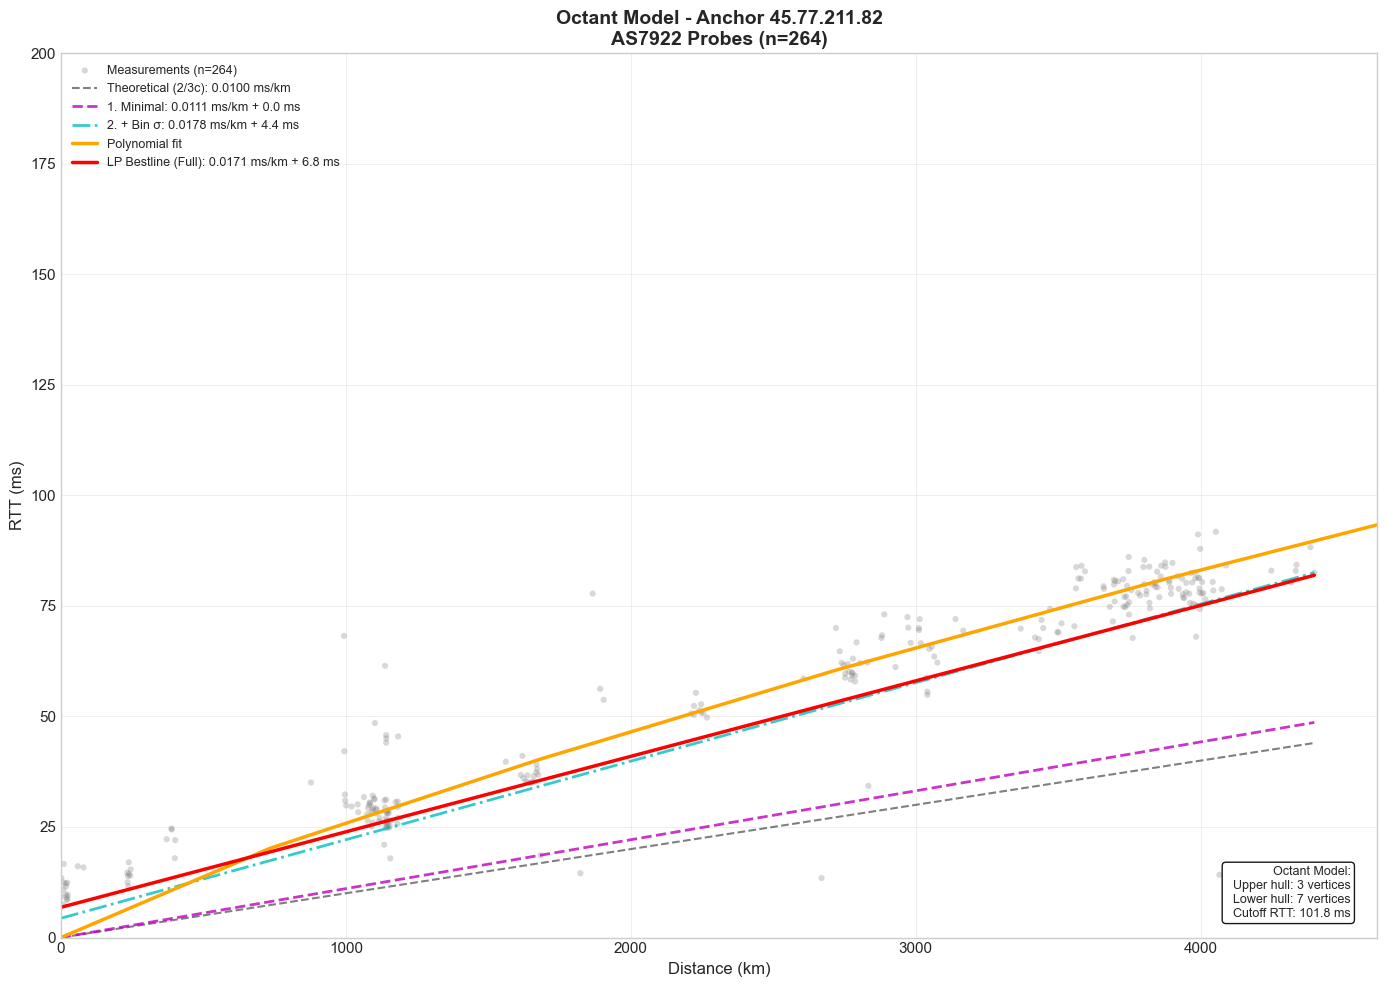


Processing anchor 66.42.119.57...
  Octant fitted: Hull: 7 upper, 8 lower vertices. Poly R²=0.868


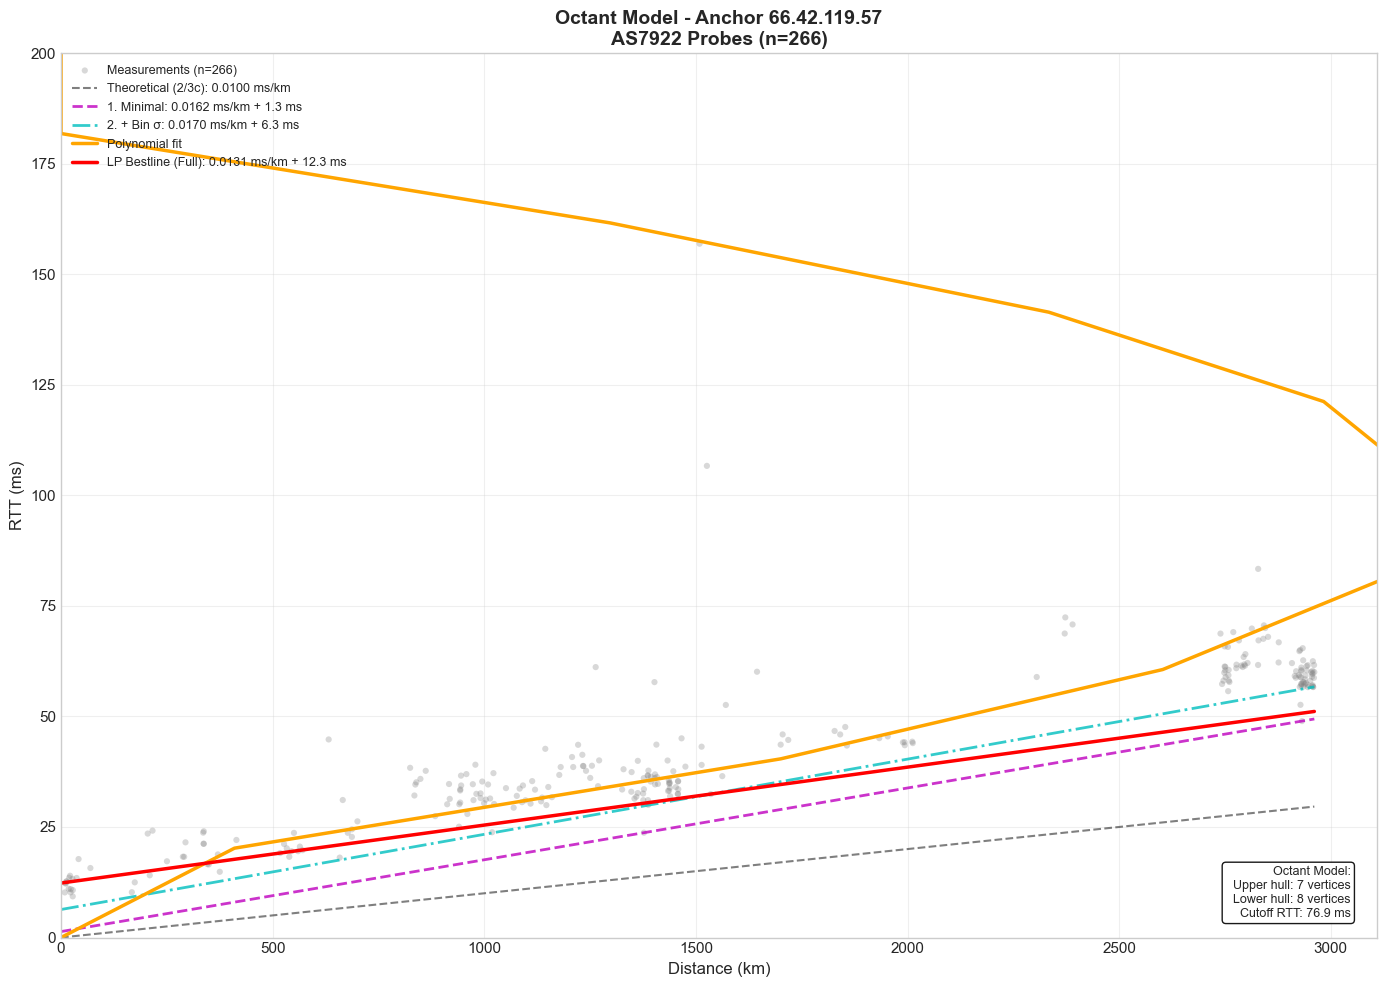


Processing anchor 144.202.18.114...
  Octant fitted: Hull: 4 upper, 3 lower vertices. Poly R²=0.761


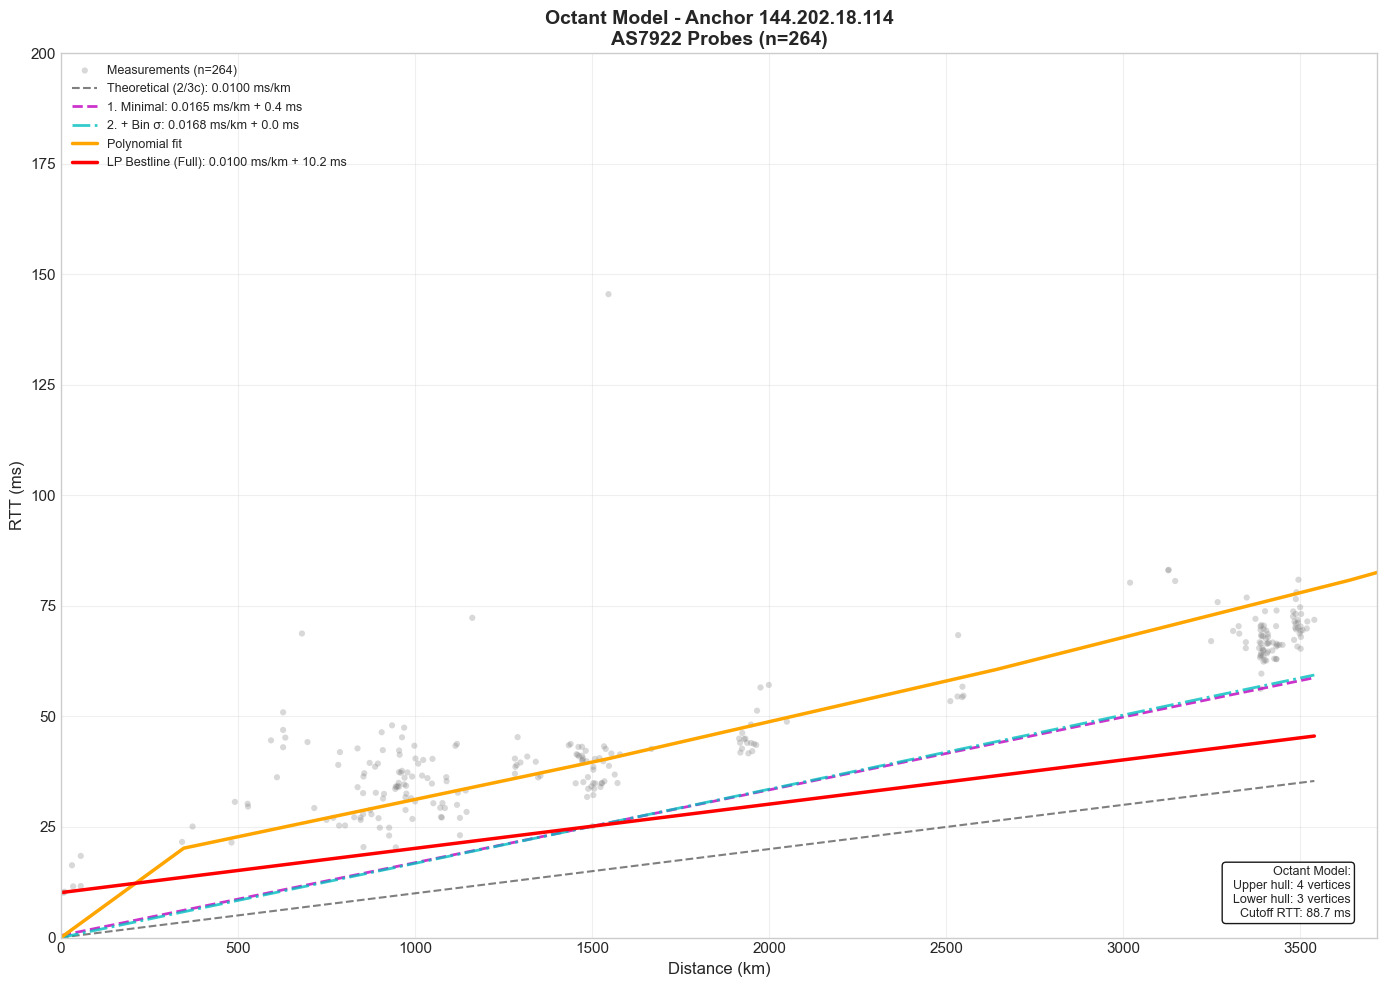


Processing anchor 149.28.210.233...
  Octant fitted: Hull: 5 upper, 7 lower vertices. Poly R²=0.935


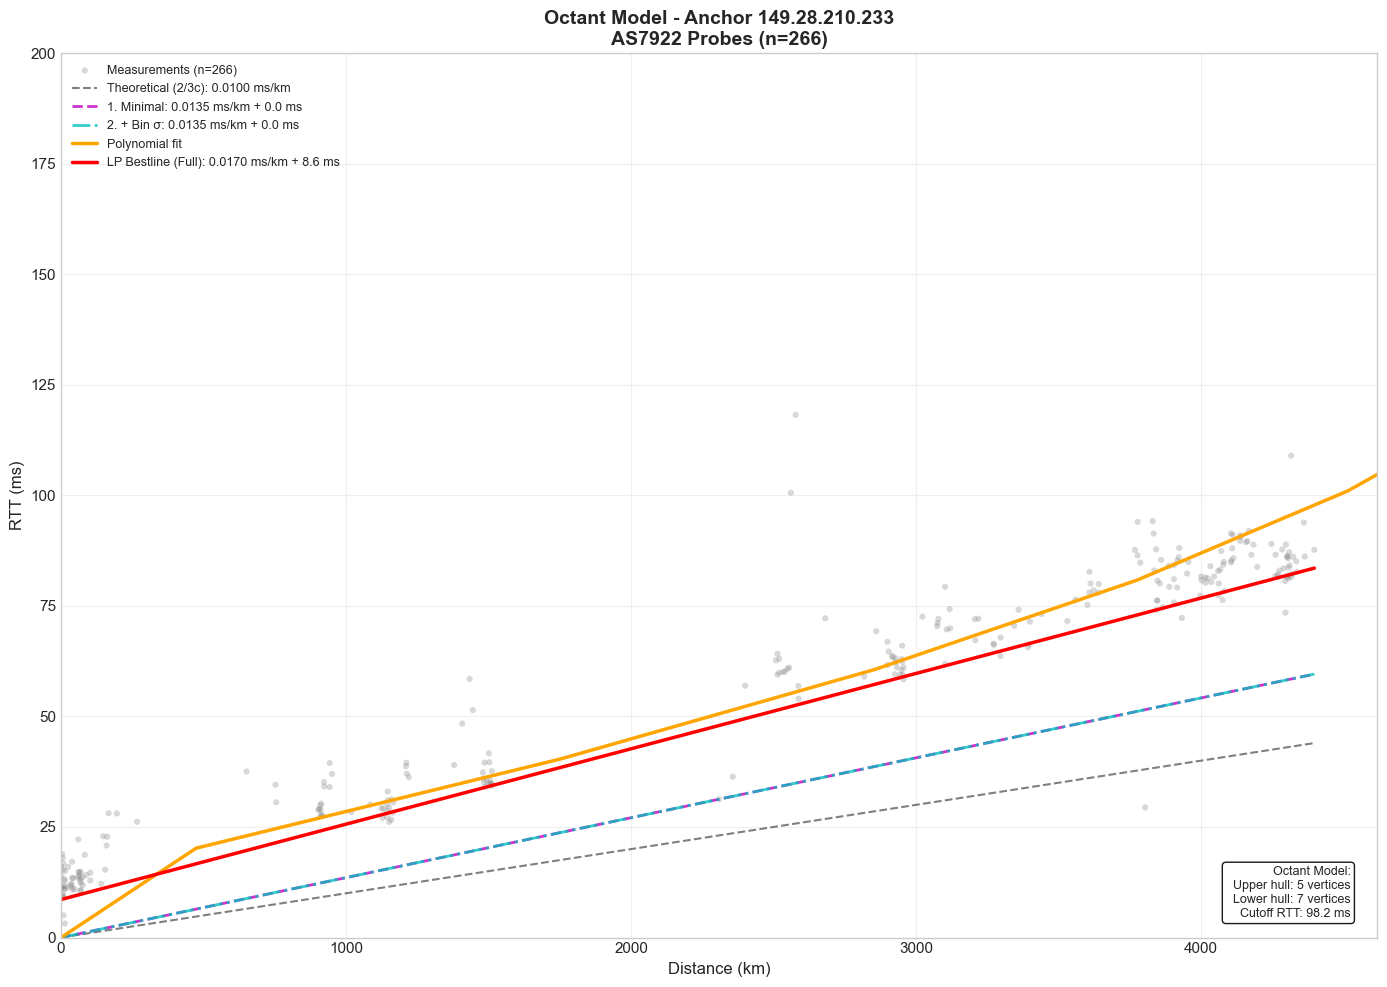


Processing anchor 149.248.18.65...
  Octant fitted: Hull: 4 upper, 3 lower vertices. Poly R²=0.874


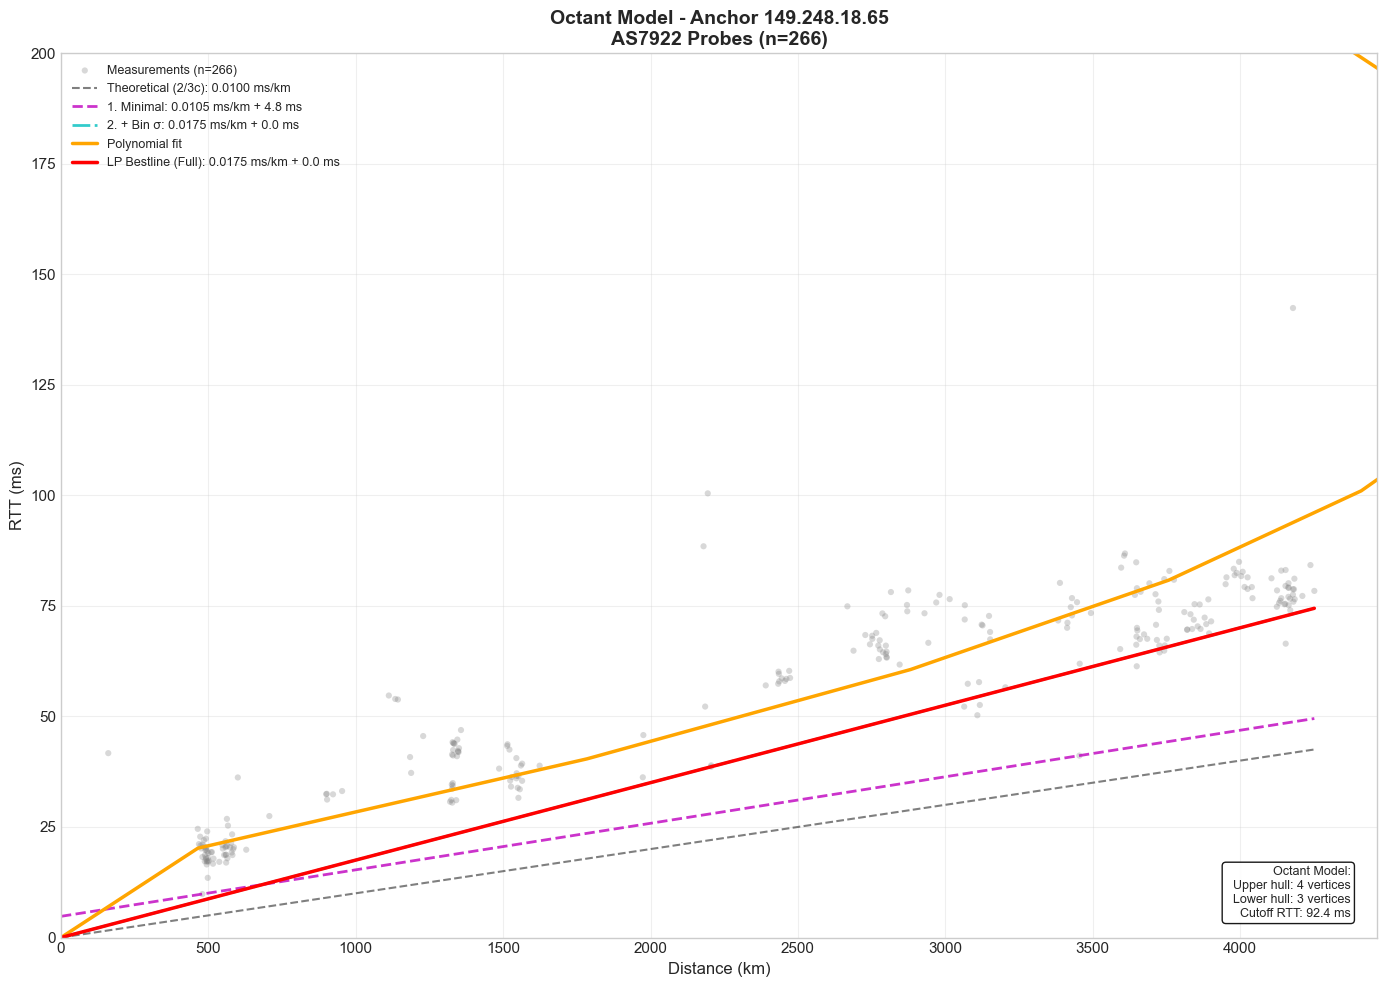


Processing anchor 207.148.2.169...
  Octant fitted: Hull: 4 upper, 5 lower vertices. Poly R²=0.588


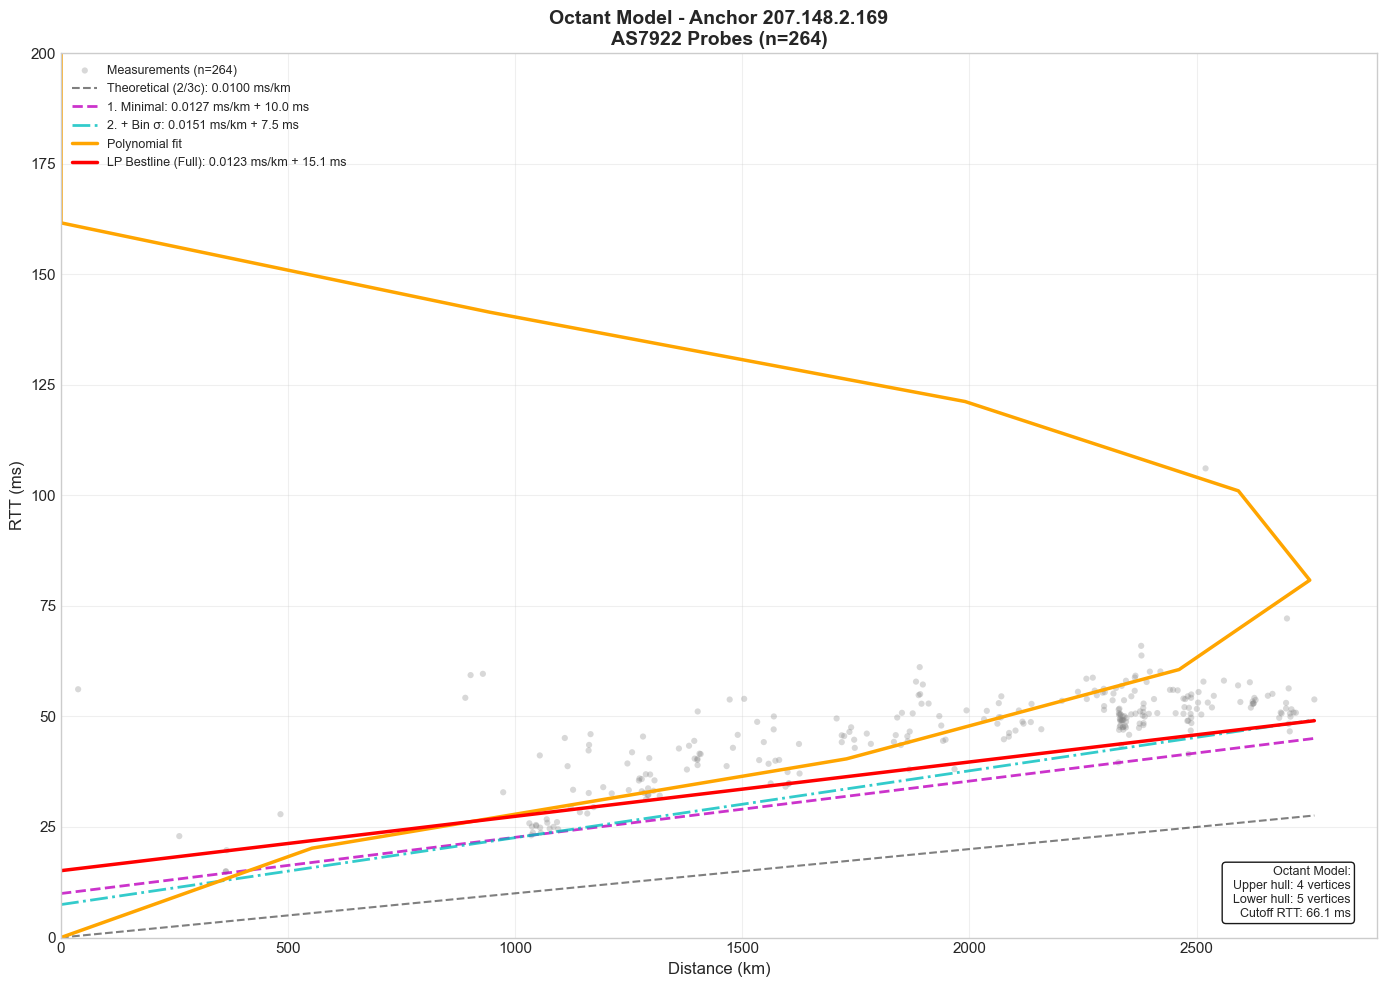


Processing anchor 207.246.74.246...
  Octant fitted: Hull: 7 upper, 4 lower vertices. Poly R²=0.805


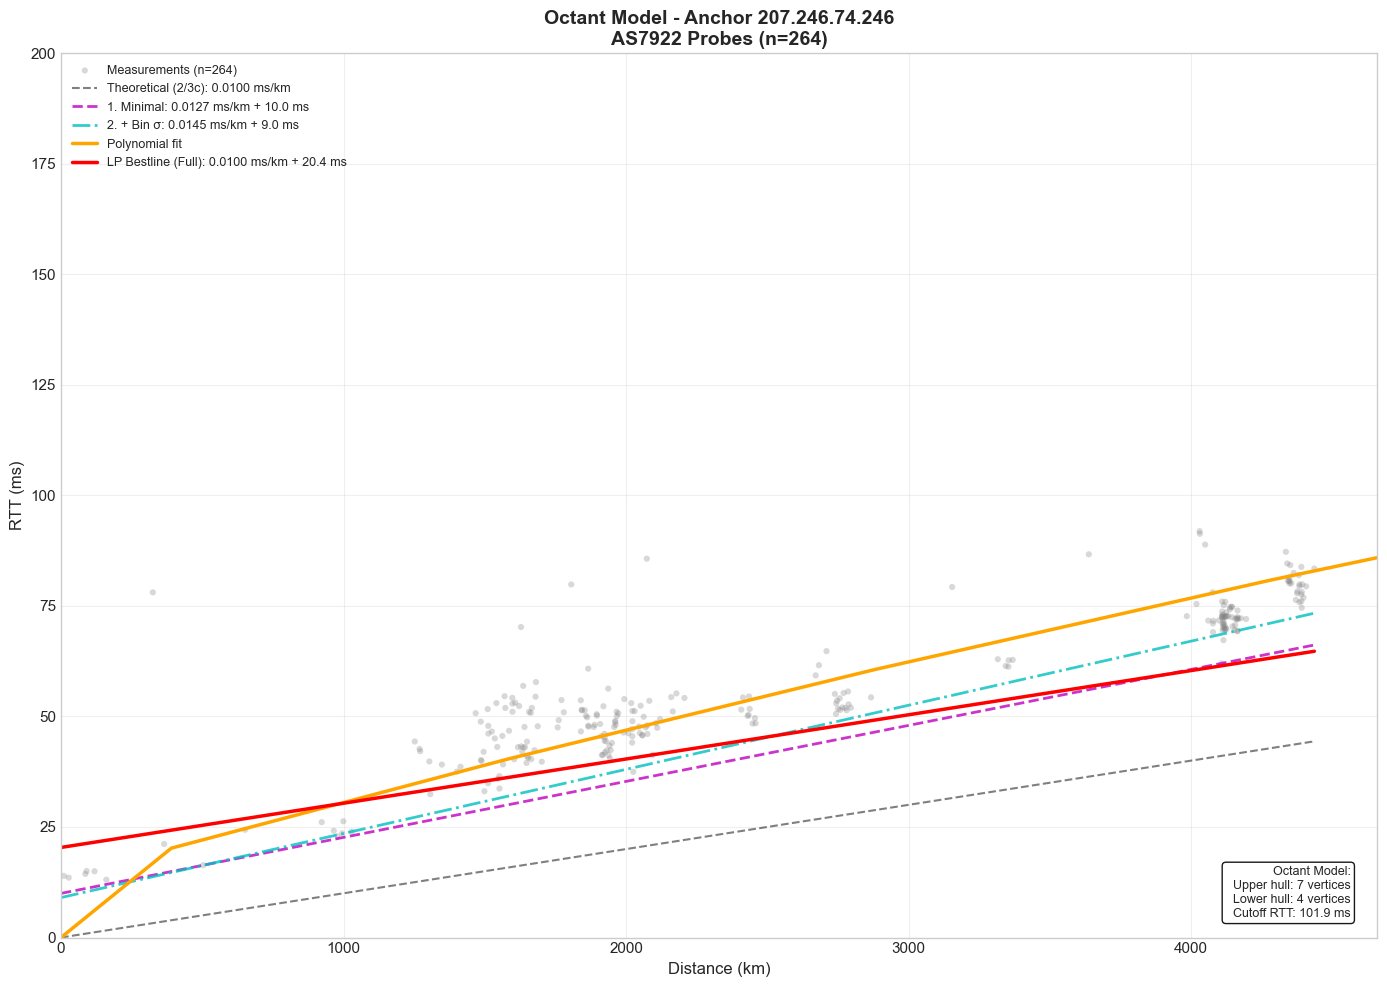

In [33]:
# Generate Octant plots for each anchor
octant_models = {}

for anchor_ip, data in results.items():
    distances = data['distances']
    rtts = data['rtts']
    filter_results = data['configs']  # Contains all filter config results
    
    # Get LP model if available
    lp_model = models.get(anchor_ip)
    
    print(f"\nProcessing anchor {anchor_ip}...")
    fig, octant_model = plot_octant_scatter(
        anchor_ip, distances, rtts, 
        lp_model=lp_model,
        filter_results=filter_results,
        max_rtt_ms=2000,
        target_coverage=0.90
    )
    
    octant_models[anchor_ip] = octant_model
    
    if octant_model.fitted:
        print(f"  Octant fitted: {octant_model.fit_message}")
    
    plt.show()
    plt.close()

In [ ]:
# Save Octant scatter plots
from pathlib import Path

octant_output_dir = Path('outputs/vultr-7922-octant')
octant_output_dir.mkdir(parents=True, exist_ok=True)

for anchor_ip, data in results.items():
    distances = data['distances']
    rtts = data['rtts']
    filter_results = data['configs']
    lp_model = models.get(anchor_ip)
    
    fig, _ = plot_octant_scatter(
        anchor_ip, distances, rtts,
        lp_model=lp_model,
        filter_results=filter_results,
        max_rtt_ms=2000,
        target_coverage=0.90
    )
    
    output_path = octant_output_dir / f"scatter_{anchor_ip.replace('.', '_')}.png"
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f"Saved: {output_path}")

# Save Octant models
for anchor_ip, model in octant_models.items():
    model_path = octant_output_dir / f"{anchor_ip.replace('.', '_')}.pkl"
    model.save(model_path)
    print(f"Saved model: {model_path}")

print(f"\nAll Octant plots and models saved to {octant_output_dir}")

## Octant Model Summary

Compare the Octant convex hull bounds with LP bestline:

| Anchor | Upper Hull Vertices | Lower Hull Vertices | Cutoff RTT | LP Slope | LP Intercept |
|--------|---------------------|---------------------|------------|----------|--------------|

In [ ]:
# Print summary table
print("=" * 80)
print("OCTANT MODEL SUMMARY")
print("=" * 80)
print(f"{'Anchor IP':<18} {'Upper':<8} {'Lower':<8} {'Cutoff':<10} {'LP Slope':<12} {'LP Intercept':<12}")
print("-" * 80)

for anchor_ip, octant_model in octant_models.items():
    lp_model = models.get(anchor_ip)
    
    upper_v = len(octant_model.hull_upper_rtts) if octant_model.fitted else 'N/A'
    lower_v = len(octant_model.hull_lower_rtts) if octant_model.fitted else 'N/A'
    cutoff = f"{octant_model.cutoff_rtt:.1f} ms" if octant_model.fitted else 'N/A'
    lp_slope = f"{lp_model.slope:.5f}" if lp_model and lp_model.fitted else 'N/A'
    lp_intercept = f"{lp_model.intercept:.2f} ms" if lp_model and lp_model.fitted else 'N/A'
    
    print(f"{anchor_ip:<18} {str(upper_v):<8} {str(lower_v):<8} {cutoff:<10} {lp_slope:<12} {lp_intercept:<12}")

print("=" * 80)